/root/miniconda3/lib/python3.8/site-packages/matplotlib/backends/backend_agg.py:240: RuntimeWarning: Glyph 26679 missing from current font.
  font.set_text(s, 0.0, flags=flags)
/root/miniconda3/lib/python3.8/site-packages/matplotlib/backends/backend_agg.py:240: RuntimeWarning: Glyph 26412 missing from current font.
  font.set_text(s, 0.0, flags=flags)
/root/miniconda3/lib/python3.8/site-packages/matplotlib/backends/backend_agg.py:240: RuntimeWarning: Glyph 20540 missing from current font.
  font.set_text(s, 0.0, flags=flags)
/root/miniconda3/lib/python3.8/site-packages/matplotlib/backends/backend_agg.py:240: RuntimeWarning: Glyph 20998 missing from current font.
  font.set_text(s, 0.0, flags=flags)
/root/miniconda3/lib/python3.8/site-packages/matplotlib/backends/backend_agg.py:240: RuntimeWarning: Glyph 24067 missing from current font.
  font.set_text(s, 0.0, flags=flags)
/root/miniconda3/lib/python3.8/site-packages/matplotlib/backends/backend_agg.py:240: RuntimeWarning: Glyph 31665 mi

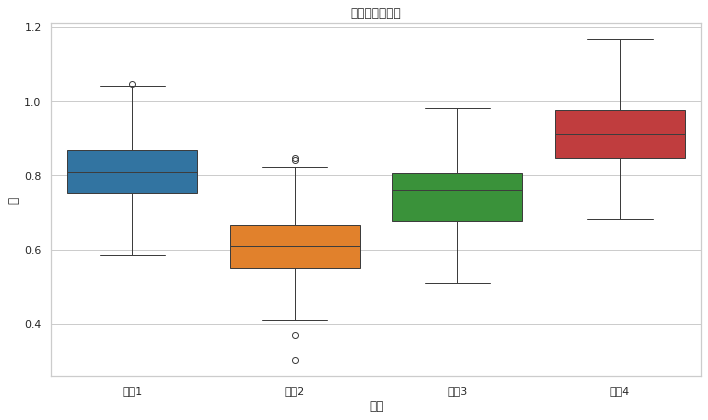

In [4]:


# 生成示例数据
np.random.seed(10)
data = {
    '样本1': np.random.normal(loc=0.8, scale=0.1, size=100),
    '样本2': np.random.normal(loc=0.6, scale=0.1, size=100),
    '样本3': np.random.normal(loc=0.75, scale=0.1, size=100),
    '样本4': np.random.normal(loc=0.9, scale=0.1, size=100)
}

# 将数据转换为 DataFrame
df = pd.DataFrame(data)

# 设置 Seaborn 样式
sns.set(style="whitegrid")

# 绘制箱形图
plt.figure(figsize=(10, 6))
# sns.boxplot(data=df, palette='viridis')
sns.boxplot(data=df, palette=['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728'])
# 添加标题和标签
plt.title('样本分布箱形图')
plt.xlabel('样本')
plt.ylabel('值')

# 显示图形
plt.tight_layout()
plt.show()


In [6]:

from data_loader_saver import load_data
import os 
from tqdm import tqdm
'''分析画图

'''

factgraph_output_file_path = '/root/autodl-fs/zyq/DeFacto/data/graph_similarity_result/val/'
text_list=['abstract','candidate','humman_summary']
graph_sims = {}

for filename in tqdm(os.listdir(factgraph_output_file_path)):
    if filename.endswith('.json'):
        file_path = os.path.join(factgraph_output_file_path, filename)
        graph_data = load_data(file_path)

        key1 = 'article'
        # print(graph_data['doc_id'])
        for key2 in text_list:
            key = '%s_%s'%(key1,key2)
            if '%s_%s'%(key1,key2) not in graph_sims.keys():
                graph_sims[key] = []
            
            graph_sims[key].append(graph_data['graph_sim'][key])


  0%|          | 0/340 [00:00<?, ?it/s]

100%|██████████| 340/340 [00:31<00:00, 10.78it/s]


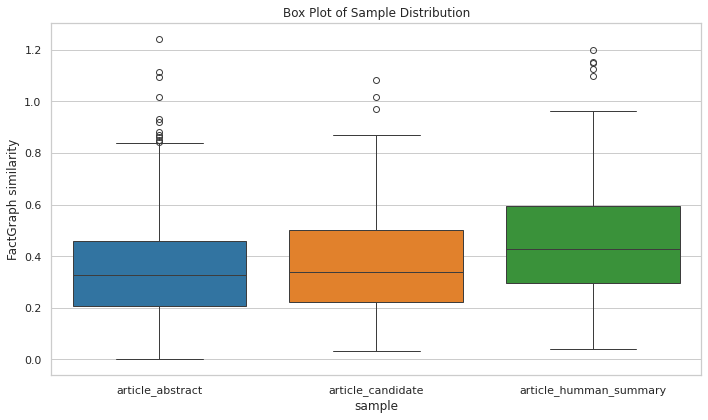

In [10]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

for k, v in graph_sims.items():
    graph_sims[k] = np.array(v)

data = graph_sims

# 将数据转换为 DataFrame
df = pd.DataFrame(data)

# 设置 Seaborn 样式
sns.set(style="whitegrid")

# 绘制箱形图
plt.figure(figsize=(10, 6))
# sns.boxplot(data=df, palette='viridis')
sns.boxplot(data=df, palette=['#1f77b4', '#ff7f0e', '#2ca02c'])
# 添加标题和标签
plt.title('Box Plot of Sample Distribution')
plt.xlabel('sample')
plt.ylabel('FactGraph similarity')

# 显示图形
plt.tight_layout()
plt.show()